In [3]:
# Portions of this code were writen with the assistance of AI tools (Gemini)

import pandas as pd
import numpy as np
import os
import glob

# =========================================
# CONFIGURATION & DATA LOADING
# =========================================
stats_base_dir = "/home/csutter/DRIVE-clean/forecasting/data_final_stats/"
evaluated_fhs = ["02", "03", "04", "05", "06", "09", "12", "15", "18", "24", "30", "36", "42", "48"]
classes = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

print("Crawling directories to compile validation stats...")

all_data = []

for fh in evaluated_fhs:
    fh_dir = os.path.join(stats_base_dir, f"FH{fh}")
    stat_files = glob.glob(os.path.join(fh_dir, "*", "Final_Stats.csv"))
    
    for file in stat_files:
        df = pd.read_csv(file)
        df['Evaluated_FH'] = fh
        all_data.append(df)

master_df = pd.concat(all_data, ignore_index=True)
val_df = master_df[master_df['evaluation_subset'] == 'Validation_Only'].copy()

# Convert raw metrics to numeric
val_df['avg_recall'] = pd.to_numeric(val_df['avg_recall'])
val_df['total_acc'] = pd.to_numeric(val_df['total_acc'])
val_df['Evaluated_FH'] = pd.Categorical(val_df['Evaluated_FH'], categories=evaluated_fhs, ordered=True)

print(f"Compilation complete! Loaded {len(val_df)} validation records.")
# =========================================
# TRUE WEIGHTED AGGREGATION
# =========================================
# 1. Capture the standard deviation from the individual fold variance
std_df = val_df.groupby(['Evaluated_FH', 'model_id'])[['avg_recall', 'total_acc']].std().reset_index()
std_df.rename(columns={'avg_recall': 'Recall_Std', 'total_acc': 'Acc_Std'}, inplace=True)

# 2. Sum the raw counts across all 30 folds using your EXACT column names
count_cols = ['n_labeled_total', 'n_correct_total']
for c in classes:
    count_cols.extend([f"n_labeled_{c}", f"n_correct_{c}"])

summed_df = val_df.groupby(['Evaluated_FH', 'model_id'])[count_cols].sum().reset_index()

# 3. Calculate True Weighted Metrics (Updated to match your headers)
summed_df['total_acc'] = summed_df['n_correct_total'] / summed_df['n_labeled_total']

def calc_true_macro_recall(row):
    recalls = []
    for c in classes:
        n_labeled = row[f"n_labeled_{c}"]
        n_correct = row[f"n_correct_{c}"]
        if n_labeled > 0:
            recalls.append(n_correct / n_labeled)
        else:
            recalls.append(np.nan)
    return np.nanmean(recalls)

summed_df['avg_recall'] = summed_df.apply(calc_true_macro_recall, axis=1)

# 4. Final Aggregated DataFrame to feed to the plotter and table
true_weighted_df = pd.merge(
    summed_df[['Evaluated_FH', 'model_id', 'avg_recall', 'total_acc','n_labeled_total']], 
    std_df, 
    on=['Evaluated_FH', 'model_id']
)

Crawling directories to compile validation stats...
Compilation complete! Loaded 2520 validation records.


# Used for dissertation

In [7]:
# =========================================
# CELL 2B: SELECTIVE VISUALIZATION (BAR CHART)
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def leadtime_models(metric, metricyaxis):
    # 1. Create a copy of the TRUE WEIGHTED dataframe (so Seaborn plots the exact math)
    plot_df = true_weighted_df.copy()

    # 2. Rename models for the legend
    model_name_map = {
        "modelFH02": "FH02-trained model",
        "modelFH09": "FH09-trained model",
        "modelFH24": "FH24-trained model"
    }
    plot_df['model_label'] = plot_df['model_id'].map(model_name_map)

    # Note: Masking logic completely removed so all 3 models appear at every FH!

    # 3. VISUALIZATION
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})

    custom_palette = {
        "FH02-trained model": "#9ecae1", 
        "FH09-trained model": "#4292c6", 
        "FH24-trained model": "#084594"  
    }

    ordered_models = ["FH02-trained model", "FH09-trained model", "FH24-trained model"]

    plt.figure(figsize=(14, 6))

    ax = sns.barplot(
        data=plot_df, 
        x='Evaluated_FH', 
        y=metric, 
        hue='model_label', 
        hue_order=ordered_models,
        palette=custom_palette,
        ci=None,            
        edgecolor="black"   
    )

    plt.title(f'Model Validation {metricyaxis}:\nComparing Performance of Models Trained on Different Lead Times', pad=15, fontsize=16, fontweight='bold')
    plt.xlabel('Evaluated FH Data', fontweight='bold')
    plt.ylabel(metricyaxis, fontweight='bold')
    plt.legend(title='Trained Model Source', bbox_to_anchor=(0, .25), loc='upper left')

    plt.tight_layout()
    plt.show()

In [4]:
# =========================================
# CELL 2B: SELECTIVE VISUALIZATION (BAR CHART)
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def leadtime_models(metric, metricyaxis):
    # 1. Create a copy of the TRUE WEIGHTED dataframe (so Seaborn plots the exact math)
    plot_df = true_weighted_df.copy()

    # 2. Convert Evaluated_FH to integers so we can check if it is < 24
    plot_df['fh_numeric'] = pd.to_numeric(plot_df['Evaluated_FH'].astype(str))

    # 3. Rename models for the legend
    model_name_map = {
        "modelFH02": "FH02-trained model",
        "modelFH09": "FH09-trained model",
        "modelFH24": "FH24-trained model"
    }
    plot_df['model_label'] = plot_df['model_id'].map(model_name_map)

    # 4. MASKING LOGIC: Hide models where the evaluated hour is less than their training hour
    mask_to_hide_24 = (plot_df['model_id'] == 'modelFH24') & (plot_df['fh_numeric'] < 24)
    mask_to_hide_09 = (plot_df['model_id'] == 'modelFH09') & (plot_df['fh_numeric'] < 9)

    # Set the metric to NaN for both masks so Seaborn leaves a blank space
    plot_df.loc[mask_to_hide_24 | mask_to_hide_09, metric] = np.nan 

    # 5. VISUALIZATION
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})

    custom_palette = {
        "FH02-trained model": "#9ecae1", 
        "FH09-trained model": "#4292c6", 
        "FH24-trained model": "#084594"  
    }

    ordered_models = ["FH02-trained model", "FH09-trained model", "FH24-trained model"]

    plt.figure(figsize=(14, 6))

    ax = sns.barplot(
        data=plot_df, 
        x='Evaluated_FH', 
        y=metric, 
        hue='model_label', 
        hue_order=ordered_models,
        palette=custom_palette,
        ci=None,            
        edgecolor="black"   
    )

    plt.title(f'Model Validation {metricyaxis}:\nComparing Performance of Models Trained on Different Lead Times', pad=15, fontsize=16, fontweight='bold')
    plt.xlabel('Evaluated FH Data', fontweight='bold')
    plt.ylabel(metricyaxis, fontweight='bold')
    plt.legend(title='Trained Model Source', bbox_to_anchor=(0, .25), loc='upper left')

    plt.tight_layout()
    plt.show()

In [2]:
# =========================================
# CELL 2B: SELECTIVE VISUALIZATION (BAR CHART)
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

def leadtime_models(metric, metricyaxis):
    # 1. Create a copy of the TRUE WEIGHTED dataframe (so Seaborn plots the exact math)
    plot_df = true_weighted_df.copy()

    # 2. Convert Evaluated_FH to integers so we can check if it is < 24
    plot_df['fh_numeric'] = pd.to_numeric(plot_df['Evaluated_FH'].astype(str))

    # 3. Rename models for the legend
    model_name_map = {
        "modelFH02": "FH02-trained model",
        "modelFH09": "FH09-trained model",
        "modelFH24": "FH24-trained model"
    }
    plot_df['model_label'] = plot_df['model_id'].map(model_name_map)

    # 4. MASKING LOGIC: Find the FH24 model where the evaluated hour is less than 24
    mask_to_hide = (plot_df['model_id'] == 'modelFH24') & (plot_df['fh_numeric'] < 24)

    # Set the metric to NaN so Seaborn leaves a blank space for it
    plot_df.loc[mask_to_hide, metric] = np.nan 

    # 5. VISUALIZATION
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({'font.size': 12})

    custom_palette = {
        "FH02-trained model": "#9ecae1", 
        "FH09-trained model": "#4292c6", 
        "FH24-trained model": "#084594"  
    }

    ordered_models = ["FH02-trained model", "FH09-trained model", "FH24-trained model"]

    plt.figure(figsize=(14, 6))

    ax = sns.barplot(
        data=plot_df, 
        x='Evaluated_FH', 
        y=metric, 
        hue='model_label', 
        hue_order=ordered_models,
        palette=custom_palette,
        ci=None,            
        edgecolor="black"   
    )

    plt.title(f'Model Validation {metricyaxis}:\nComparing Performance of Models Trained on Different Lead Times', pad=15, fontsize=16, fontweight='bold')
    plt.xlabel('Evaluated FH Data', fontweight='bold')
    plt.ylabel(metricyaxis, fontweight='bold')
    plt.legend(title='Trained Model Source', bbox_to_anchor=(0, .25), loc='upper left')

    plt.tight_layout()
    plt.show()

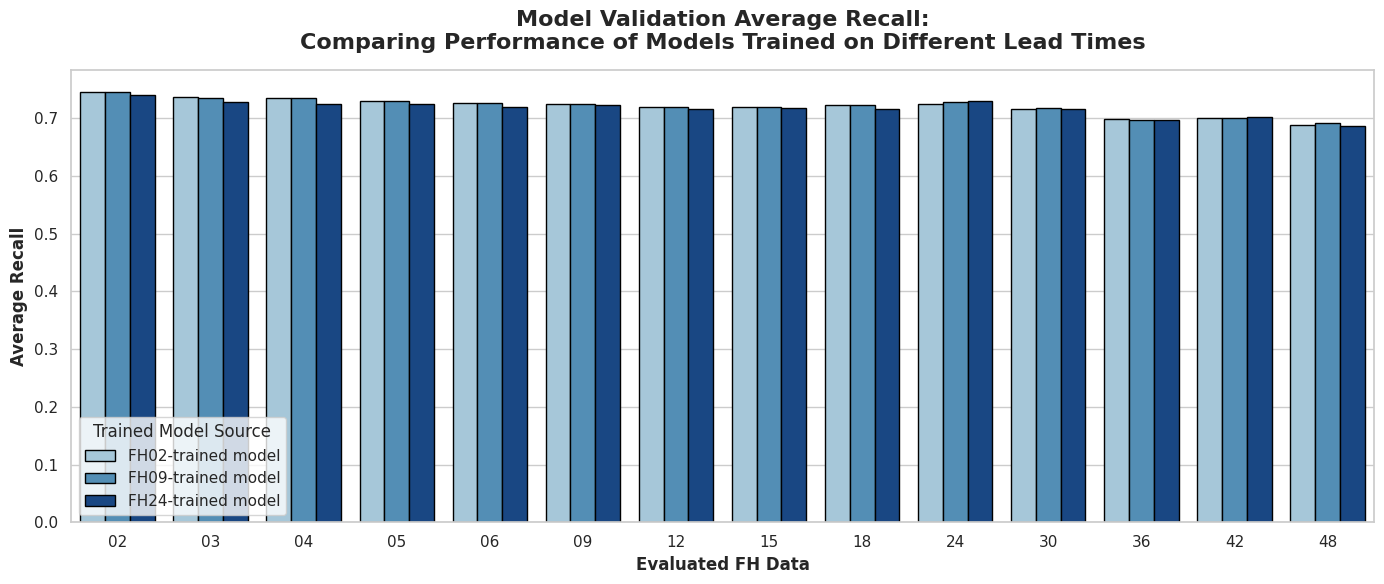

In [8]:
leadtime_models(metric = "avg_recall", metricyaxis = "Average Recall")

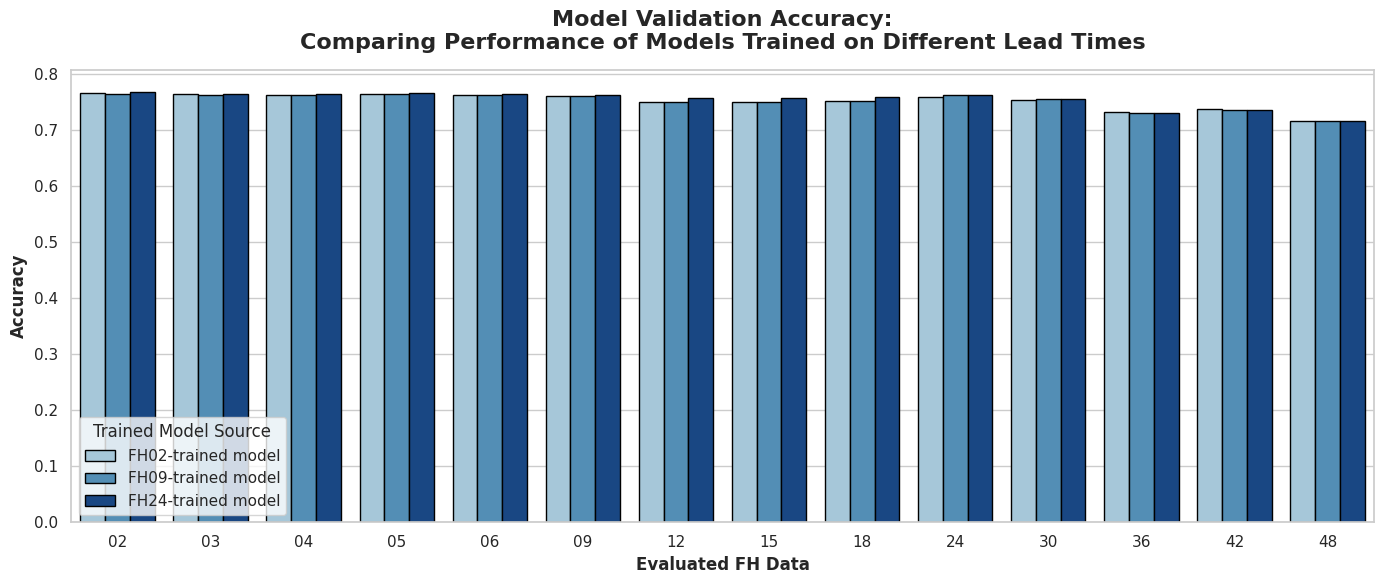

In [9]:
leadtime_models(metric = "total_acc", metricyaxis = "Accuracy")

In [5]:
# =========================================
# CELL 3: NUMERICAL SUMMARY TABLE
# =========================================

# Display the table directly from the pre-aggregated true_weighted_df
display_df = true_weighted_df.copy()

# Rename columns to match your desired output
display_df.rename(columns={
    'model_id': 'Trained_Model',
    'avg_recall': 'Recall_Mean',
    'total_acc': 'Acc_Mean',
    'n_labeled_total': 'Support'  # <-- Rename the raw count column
}, inplace=True)

# Reorder columns logically (Support placed right after the model name)
display_df = display_df[['Evaluated_FH', 'Trained_Model', 'Support', 'Recall_Mean', 'Recall_Std', 'Acc_Mean', 'Acc_Std']]

# Format for clean reading
display_df['Support'] = display_df['Support'].astype(int).map('{:,}'.format) # <-- Adds commas to large numbers
display_df['Recall_Mean'] = display_df['Recall_Mean'].map('{:.4f}'.format)
display_df['Recall_Std'] = display_df['Recall_Std'].map('± {:.4f}'.format)
display_df['Acc_Mean'] = display_df['Acc_Mean'].map('{:.4f}'.format)
display_df['Acc_Std'] = display_df['Acc_Std'].map('± {:.4f}'.format)

print("=== TRUE WEIGHTED NUMERICAL SUMMARY ACROSS 30 TRACKERS ===")
display(display_df)

=== TRUE WEIGHTED NUMERICAL SUMMARY ACROSS 30 TRACKERS ===


,Evaluated_FH,Trained_Model,Support,Recall_Mean,Recall_Std,Acc_Mean,Acc_Std
0,02,modelFH02,"214,890",0.7460,± 0.0497,0.7654,± 0.0277
1,02,modelFH09,"214,890",0.7445,± 0.0488,0.7643,± 0.0270
2,02,modelFH24,"214,890",0.7395,± 0.0486,0.7683,± 0.0258
3,03,modelFH02,"214,890",0.7370,± 0.0513,0.7631,± 0.0265
4,03,modelFH09,"214,890",0.7355,± 0.0523,0.7625,± 0.0267
5,03,modelFH24,"214,890",0.7282,± 0.0503,0.7637,± 0.0242
6,04,modelFH02,"214,890",0.7350,± 0.0500,0.7618,± 0.0278
7,04,modelFH09,"214,890",0.7343,± 0.0495,0.7621,± 0.0274
8,04,modelFH24,"214,890",0.7251,± 0.0519,0.7648,± 0.0272
9,05,modelFH02,"214,890",0.7293,± 0.0519,0.7632,± 0.0249


In [2]:
# Calculate Mean and Standard Deviation across the 30 trackers
summary_stats = val_df.groupby(['Evaluated_FH', 'model_id'])[['avg_recall', 'total_acc']].agg(['mean', 'std']).reset_index()

# Flatten the multi-level columns for readability
summary_stats.columns = ['Evaluated_FH', 'Trained_Model', 'Recall_Mean', 'Recall_Std', 'Acc_Mean', 'Acc_Std']

# Display the table, formatted for clean reading
display_df = summary_stats.copy()
display_df['Recall_Mean'] = display_df['Recall_Mean'].map('{:.4f}'.format)
display_df['Recall_Std'] = display_df['Recall_Std'].map('± {:.4f}'.format)
display_df['Acc_Mean'] = display_df['Acc_Mean'].map('{:.4f}'.format)
display_df['Acc_Std'] = display_df['Acc_Std'].map('± {:.4f}'.format)

print("=== NUMERICAL SUMMARY ACROSS 30 TRACKERS ===")
display(display_df)

=== NUMERICAL SUMMARY ACROSS 30 TRACKERS ===


,Evaluated_FH,Trained_Model,Recall_Mean,Recall_Std,Acc_Mean,Acc_Std
0,02,modelFH02,0.7564,± 0.0497,0.7659,± 0.0277
1,02,modelFH09,0.7547,± 0.0488,0.7648,± 0.0270
2,02,modelFH24,0.7502,± 0.0486,0.7688,± 0.0258
3,03,modelFH02,0.7479,± 0.0513,0.7635,± 0.0265
4,03,modelFH09,0.7465,± 0.0523,0.7629,± 0.0267
5,03,modelFH24,0.7395,± 0.0503,0.7641,± 0.0242
6,04,modelFH02,0.7458,± 0.0500,0.7621,± 0.0278
7,04,modelFH09,0.7451,± 0.0495,0.7623,± 0.0274
8,04,modelFH24,0.7364,± 0.0519,0.7652,± 0.0272
9,05,modelFH02,0.7414,± 0.0519,0.7634,± 0.0249


In [9]:
# 1. Calculate the mean performance across all 30 trackers for each FH / Model combo
mean_stats = val_df.groupby(['Evaluated_FH', 'model_id'], observed=True)[['avg_recall', 'total_acc']].mean().reset_index()

# 2. Find the index of the highest Recall for each FH, then extract those rows
idx_best_recall = mean_stats.groupby('Evaluated_FH')['avg_recall'].idxmax()
best_by_recall = mean_stats.loc[idx_best_recall, ['Evaluated_FH', 'model_id', 'avg_recall']]

# 3. Find the index of the highest Accuracy for each FH, then extract those rows
idx_best_acc = mean_stats.groupby('Evaluated_FH')['total_acc'].idxmax()
best_by_acc = mean_stats.loc[idx_best_acc, ['Evaluated_FH', 'model_id', 'total_acc']]

# 4. Print the final lists cleanly
print("🏆 BEST MODELS BY AVERAGE RECALL (Macro)")
print("-" * 45)
for index, row in best_by_recall.iterrows():
    print(f"Evaluated FH {row['Evaluated_FH']:>2}: {row['model_id']:<12} | Recall: {row['avg_recall']:.4f}")

print("\n")

print("🎯 BEST MODELS BY TOTAL ACCURACY")
print("-" * 45)
for index, row in best_by_acc.iterrows():
    print(f"Evaluated FH {row['Evaluated_FH']:>2}: {row['model_id']:<12} | Accuracy: {row['total_acc']:.4f}")

🏆 BEST MODELS BY AVERAGE RECALL (Macro)
---------------------------------------------
Evaluated FH 02: modelFH02    | Recall: 0.7564
Evaluated FH 03: modelFH02    | Recall: 0.7479
Evaluated FH 04: modelFH02    | Recall: 0.7458
Evaluated FH 05: modelFH09    | Recall: 0.7424
Evaluated FH 06: modelFH02    | Recall: 0.7397
Evaluated FH 09: modelFH09    | Recall: 0.7383
Evaluated FH 12: modelFH02    | Recall: 0.7296
Evaluated FH 15: modelFH09    | Recall: 0.7321
Evaluated FH 18: modelFH02    | Recall: 0.7352
Evaluated FH 24: modelFH24    | Recall: 0.7356
Evaluated FH 30: modelFH09    | Recall: 0.7253
Evaluated FH 36: modelFH02    | Recall: 0.7055
Evaluated FH 42: modelFH02    | Recall: 0.7080
Evaluated FH 48: modelFH09    | Recall: 0.6975


🎯 BEST MODELS BY TOTAL ACCURACY
---------------------------------------------
Evaluated FH 02: modelFH24    | Accuracy: 0.7688
Evaluated FH 03: modelFH24    | Accuracy: 0.7641
Evaluated FH 04: modelFH24    | Accuracy: 0.7652
Evaluated FH 05: modelFH24   

# Conclusion:
- FH24-trained was only trained on 15% of the data. Minimal training examples - don't want to use this data unless it is significantly better for longer lead times than the FH02- or FH09- trained models. 
- See in plots that it's not significantly better using avg recall (which we care more about, esp since accuracy may just be getting the dry right in the FH24 models)
- Using more data from a model trained on FH02 or FH09 has *more benefit* than using data that has more "aligned" lead time

# Other plot drafts

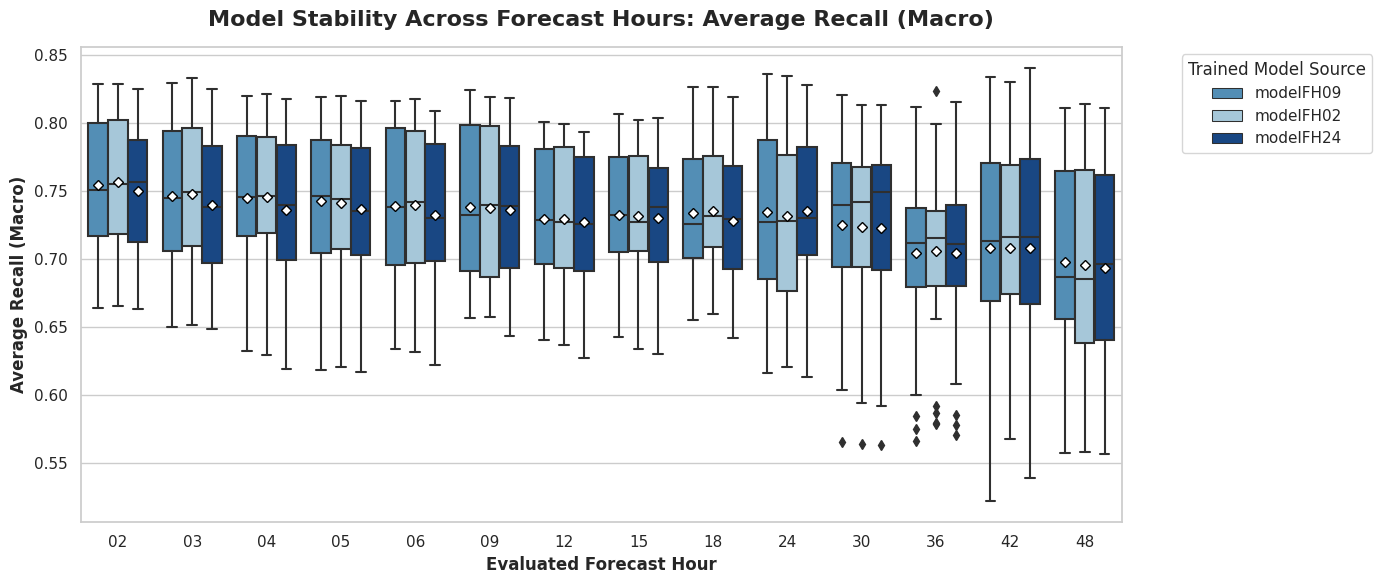

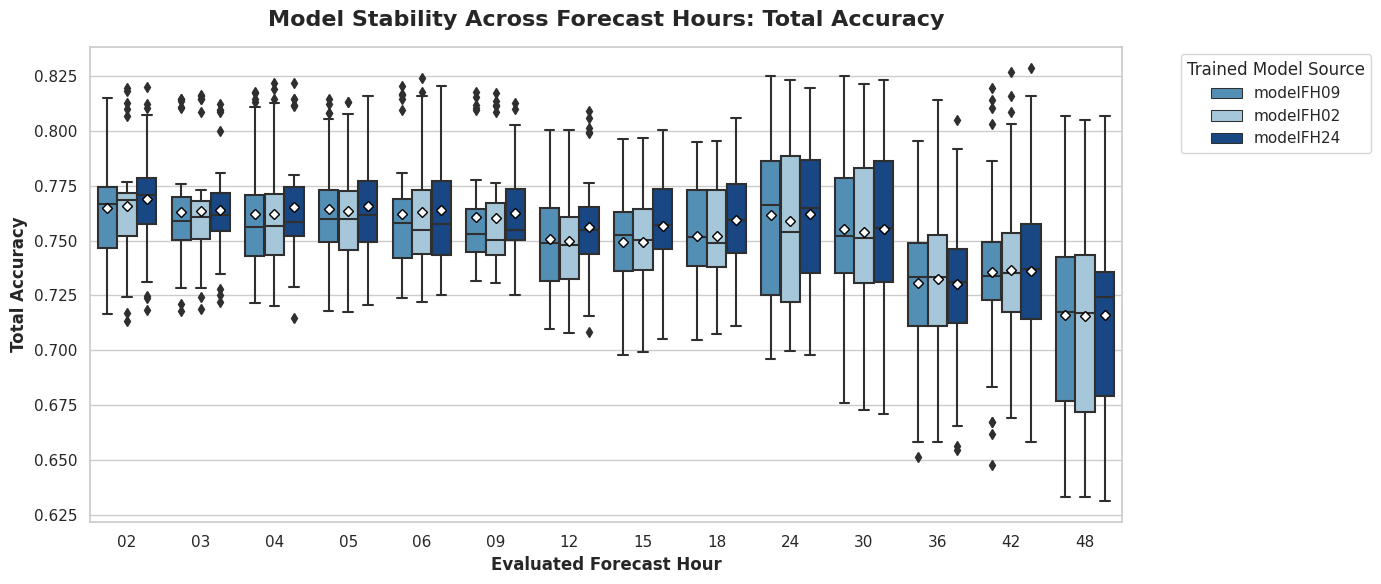

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

metrics_to_plot = {
    'avg_recall': 'Average Recall (Macro)',
    'total_acc': 'Total Accuracy'
}

# Custom intuitive palette: Lightest (FH02) -> Medium (FH09) -> Darkest (FH24)
custom_palette = {
    "modelFH02": "#9ecae1", 
    "modelFH09": "#4292c6", 
    "modelFH24": "#084594"  
}

for metric_col, metric_name in metrics_to_plot.items():
    plt.figure(figsize=(14, 6))
    
    # Create grouped boxplots
    ax = sns.boxplot(
        data=val_df, 
        x='Evaluated_FH', 
        y=metric_col, 
        hue='model_id',
        palette=custom_palette, # <-- Updated to use the custom blue scheme
        showmeans=True,
        meanprops={"marker":"D","markerfacecolor":"white", "markeredgecolor":"black", "markersize":5}
    )
    
    plt.title(f'Model Stability Across Forecast Hours: {metric_name}', pad=15, fontsize=16, fontweight='bold')
    plt.xlabel('Evaluated Forecast Hour', fontweight='bold')
    plt.ylabel(metric_name, fontweight='bold')
    plt.legend(title='Trained Model Source', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

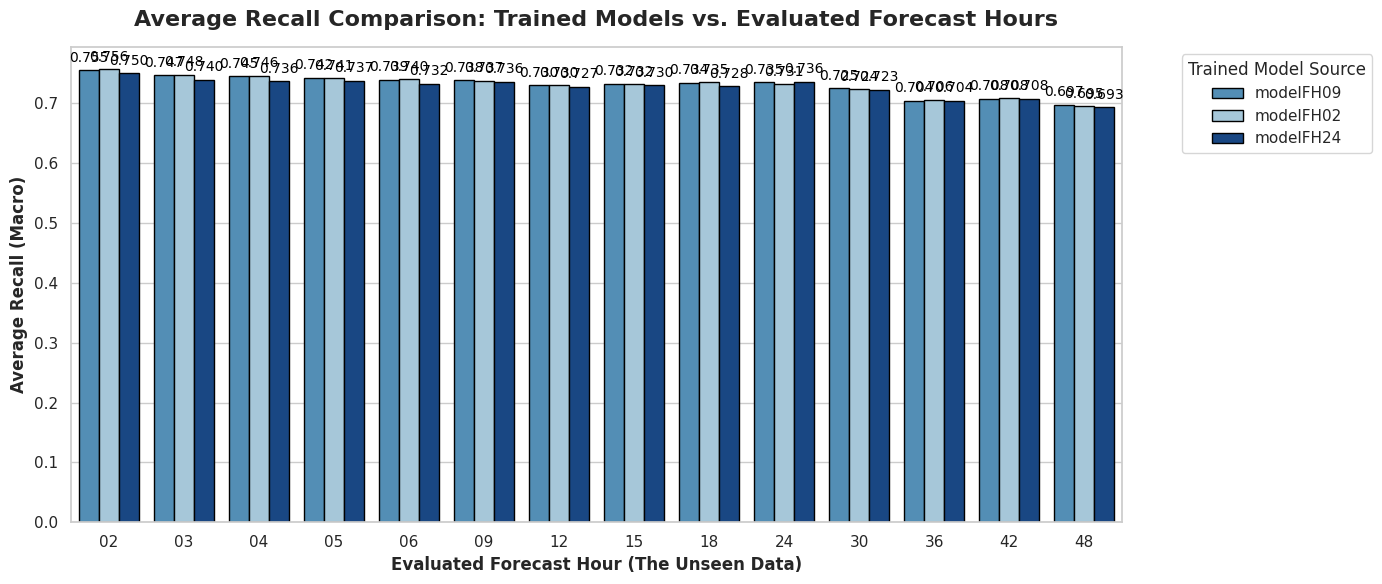

In [ ]:
# =========================================
# CELL 2: VISUALIZATION (BAR CHART)
# =========================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Intuitive palette: Lightest (FH02) -> Medium (FH09) -> Darkest (FH24)
custom_palette = {
    "modelFH02": "#9ecae1", 
    "modelFH09": "#4292c6", 
    "modelFH24": "#084594"  
}

plt.figure(figsize=(14, 6))

ax = sns.barplot(
    data=val_df, 
    x='Evaluated_FH', 
    y='avg_recall', 
    hue='model_id',
    palette=custom_palette,
    ci=None,            # <-- FIXED: Uses older Seaborn syntax to turn off variance lines
    edgecolor="black"   # Crisp borders
)

plt.title('Average Recall Comparison: Trained Models vs. Evaluated Forecast Hours', pad=15, fontsize=16, fontweight='bold')
plt.xlabel('Evaluated Forecast Hour (The Unseen Data)', fontweight='bold')
plt.ylabel('Average Recall (Macro)', fontweight='bold')
plt.legend(title='Trained Model Source', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add exact numbers on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.3f}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=10, color='black', 
                    xytext=(0, 4), 
                    textcoords='offset points')


plt.tight_layout()
plt.show()

In [ ]:
val_df

,tracker_name,model_id,algorithm,hyperparameters,evaluation_subset,n_labeled_total,n_correct_total,total_acc,avg_recall,n_labeled_snow_severe,...,n_labeled_wet,n_correct_wet,recall_wet,n_labeled_dry,n_correct_dry,recall_dry,n_labeled_poor_viz,n_correct_poor_viz,recall_poor_viz,Evaluated_FH
1,nestcv_5cat_twotrain_OT5_m0_T0V1.csv,modelFH09,RandomForest,"{'max_depth': 10, 'max_samples': 0.5, 'n_estim...",Validation_Only,3561,2884,0.809885,0.807365,231,...,1322,947,0.716339,1319,1213,0.919636,151,110,0.728477,02
5,nestcv_5cat_twotrain_OT4_m3_T5V0.csv,modelFH09,RandomForest,"{'max_depth': 10, 'max_samples': 0.5, 'n_estim...",Validation_Only,3697,2863,0.774412,0.737355,294,...,1422,1033,0.726442,1326,1136,0.856712,144,93,0.645833,02
9,nestcv_5cat_twotrain_OT5_m4_T4V0.csv,modelFH09,RandomForest,"{'max_depth': 10, 'max_samples': 0.5, 'n_estim...",Validation_Only,3697,2828,0.764945,0.719610,294,...,1422,1011,0.710970,1326,1138,0.858220,144,81,0.562500,02
13,nestcv_5cat_twotrain_OT3_m4_T2V4.csv,modelFH09,RandomForest,"{'max_depth': 10, 'max_samples': 0.5, 'n_estim...",Validation_Only,3545,2721,0.767560,0.709743,352,...,1250,870,0.696000,1375,1191,0.866182,161,70,0.434783,02
17,nestcv_5cat_twotrain_OT5_m3_T3V4.csv,modelFH09,RandomForest,"{'max_depth': 10, 'max_samples': 0.5, 'n_estim...",Validation_Only,3545,2720,0.767278,0.729409,352,...,1250,872,0.697600,1375,1176,0.855273,161,90,0.559006,02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10061,nestcv_5cat_twotrain_OT2_m3_T5V0.csv,modelFH24,RandomForest,"{'max_depth': None, 'max_samples': 0.5, 'n_est...",Validation_Only,543,350,0.644567,0.618164,43,...,190,123,0.647368,211,145,0.687204,17,11,0.647059,48
10065,nestcv_5cat_twotrain_OT4_m1_T1V2.csv,modelFH24,RandomForest,"{'max_depth': None, 'max_samples': 0.5, 'n_est...",Validation_Only,497,366,0.736419,0.766530,27,...,189,130,0.687831,186,147,0.790323,25,20,0.800000,48
10069,nestcv_5cat_twotrain_OT1_m0_T2V3.csv,modelFH24,RandomForest,"{'max_depth': None, 'max_samples': 0.5, 'n_est...",Validation_Only,559,367,0.656530,0.566598,38,...,232,141,0.607759,188,161,0.856383,24,9,0.375000,48
10073,nestcv_5cat_twotrain_OT3_m2_T4V5.csv,modelFH24,RandomForest,"{'max_depth': None, 'max_samples': 0.5, 'n_est...",Validation_Only,555,405,0.729730,0.752983,36,...,212,125,0.589623,211,184,0.872038,23,19,0.826087,48
